# **Step-1: Import Libraries**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import warnings
warnings.filterwarnings("ignore")

# **Step-2: Load Dataset**

In [6]:
df = pd.read_csv("/content/predictive_maintenance.csv")

# **Step-3: EDA**

**3.1: Basic Data Understanding**

In [8]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [10]:
df.sample(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9566,9567,L56746,L,299.8,311.1,1603,35.1,179,0,0,0,0,0,0
9495,9496,H38909,H,299.3,310.0,1373,44.8,221,0,0,0,0,0,0
3312,3313,L50492,L,301.4,310.4,1639,28.9,94,0,0,0,0,0,0
6874,6875,H36288,H,300.9,311.3,1295,58.9,77,0,0,0,0,0,0
2300,2301,L49480,L,299.3,308.6,1371,50.5,136,0,0,0,0,0,0


**3.2: Check Rows & Columns**

In [11]:
df.shape

(10000, 14)

**3.3: Check Columns Datatypes**

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

**3.4: Check Missing Values**

In [13]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


**3.5: Check Duplicated Values**

In [14]:
df.duplicated().sum()

np.int64(0)

**3.6: Check Class Imbalance**

In [15]:
df["Machine failure"].value_counts()

,count
Machine failure,
0,9661
1,339


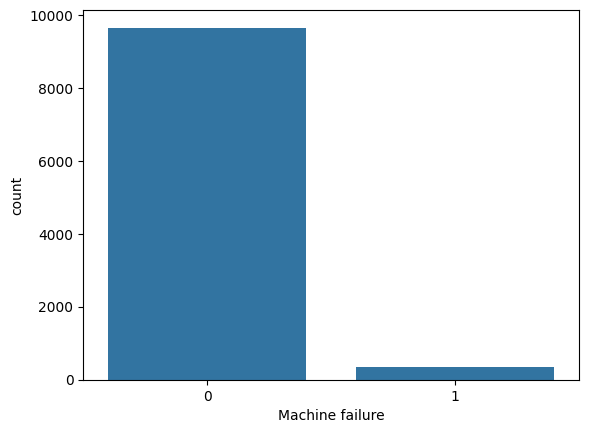

In [16]:
sns.countplot(x = df["Machine failure"])
plt.show()

**3.7: Check Outliers**

In [17]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [18]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

Index(['UDI', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

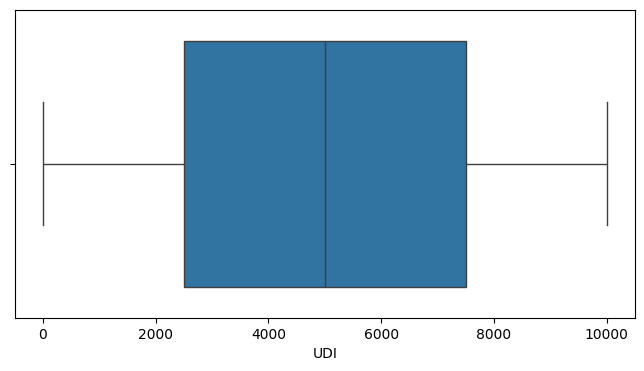

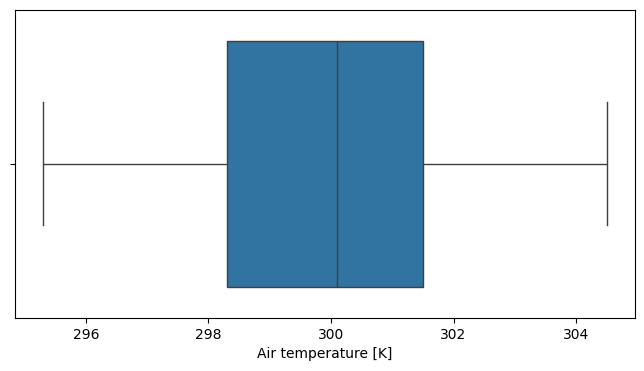

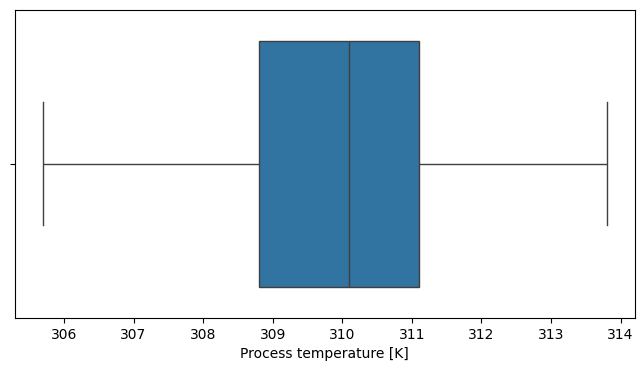

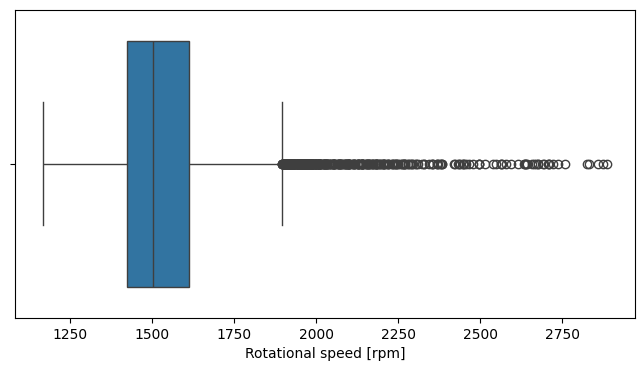

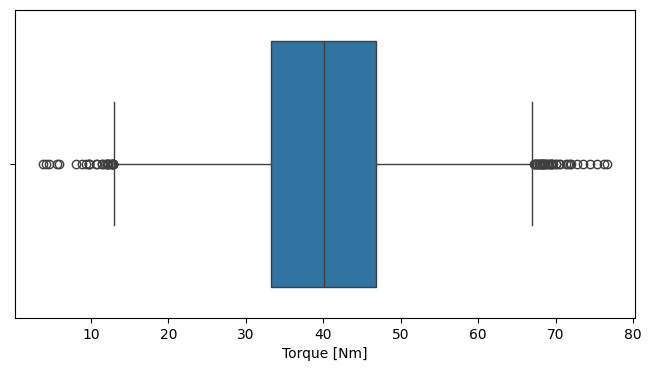

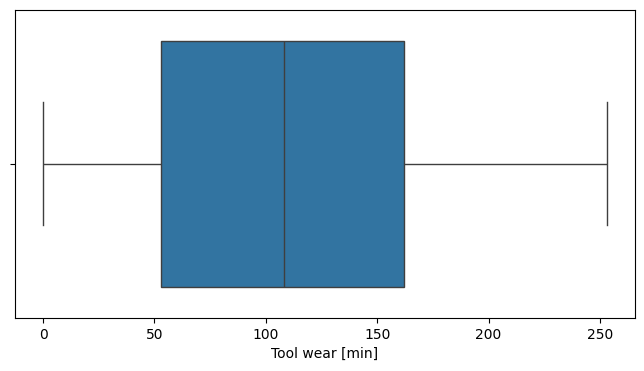

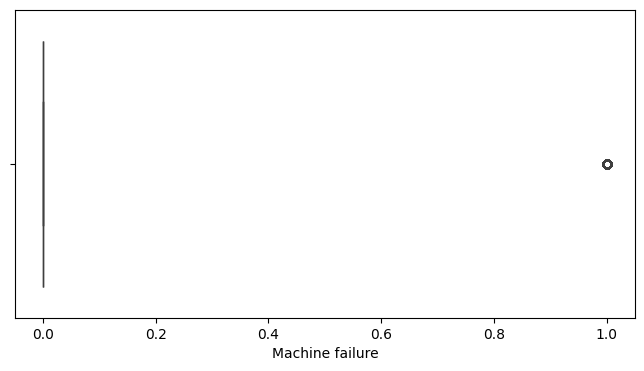

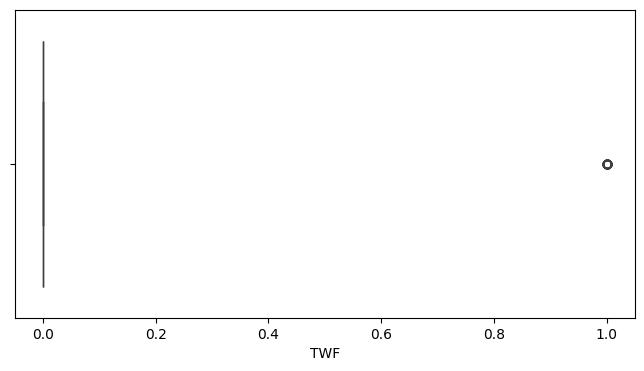

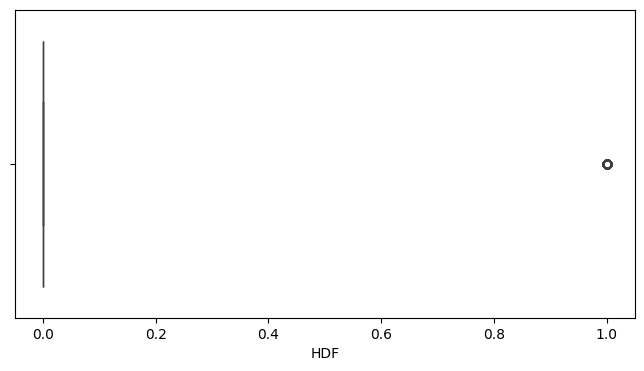

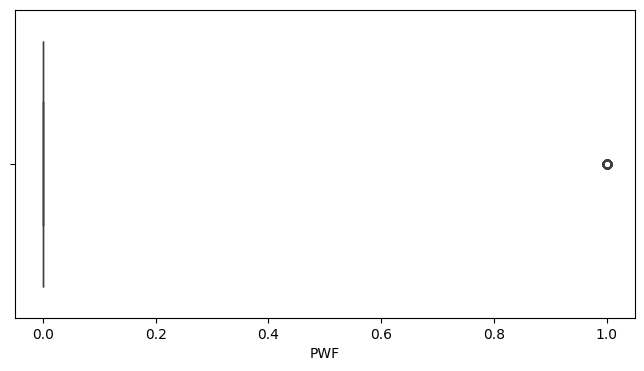

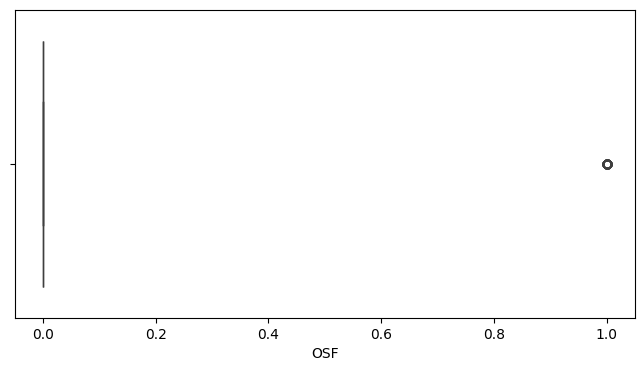

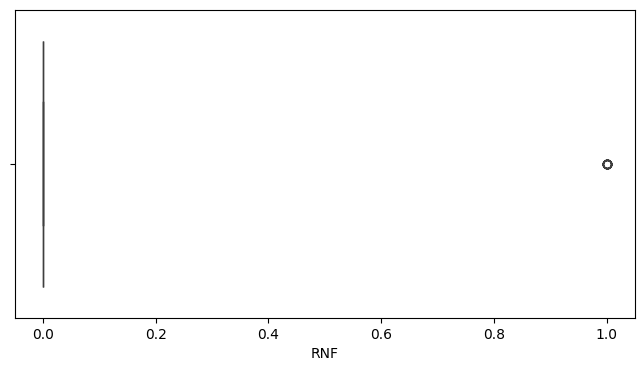

In [19]:
for i in numeric_cols:
  plt.figure(figsize=(8,4))
  sns.boxplot(x = df[i])
  plt.show()

**3.8: Check Correlation**

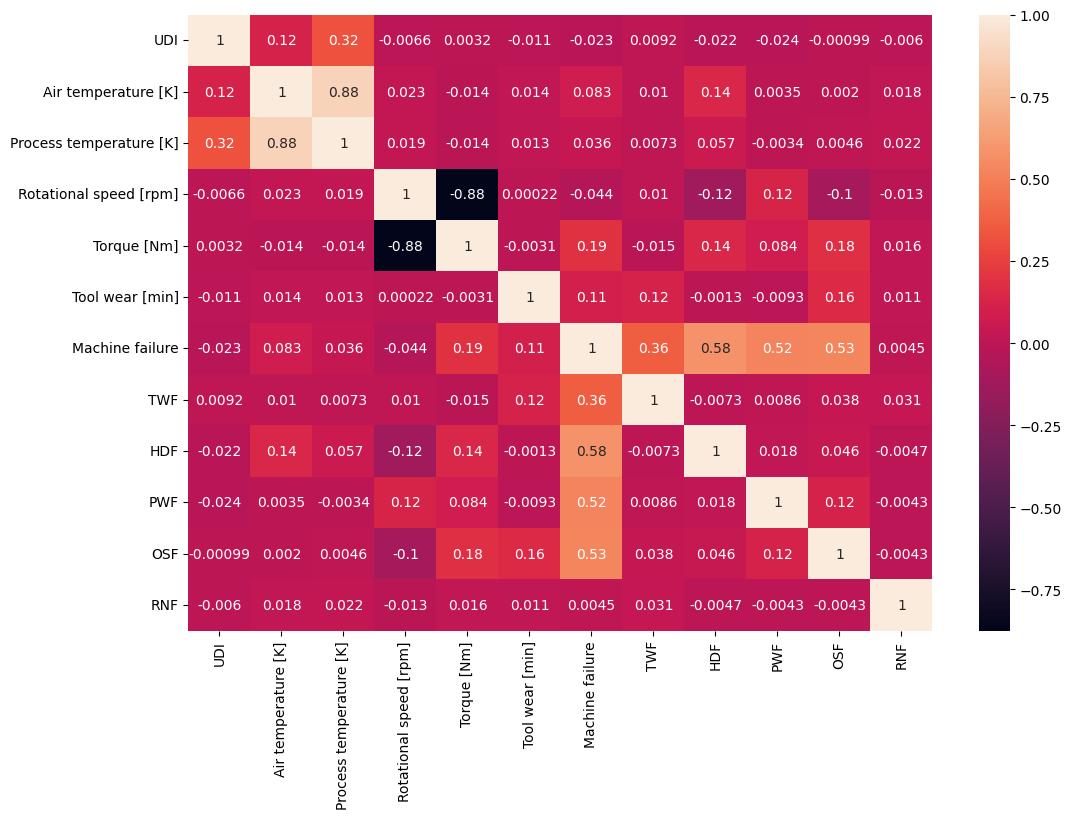

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot = True)
plt.show()

# **Step-4: Data Validaton & Handling Outliers**

In [21]:
df_copy = df.copy()

In [22]:
df_copy.drop(["UDI", "Product ID"], axis=1, inplace= True)

In [23]:
df_copy.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# **Step-5: Features, Target & Train-Test Split**

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X = df_copy.drop(["Machine failure"], axis = 1)
y = df_copy["Machine failure"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [27]:
numeric_cols = X_train.select_dtypes(include=np.number).columns
numeric_cols

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [28]:
categorical_cols = ["Type"]

# **Step-6: Handle Class Imbalance**

In [29]:
np.bincount(y_train)

array([6462,  238])

In [30]:
neg, pos = np.bincount(y_train)

In [31]:
scale_weights = neg/pos

In [32]:
scale_weights

np.float64(27.15126050420168)

# **Step-7: Data Preprocessing — Pipelines & Column Transformer**

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [34]:
preprocessor_scaled = ColumnTransformer(
   transformers = [
       # Pipeline For Numeric Columns
       ("numeric", Pipeline(
           [
                ("imputer", SimpleImputer(strategy = "median")),
                ("scaler", StandardScaler())
           ]
       ), numeric_cols),
       # Pipeline For Categorical Columns
       ("categorical", Pipeline(
           [
                ("imputer", SimpleImputer(strategy = "most_frequent")),
                ("onehot", OneHotEncoder())
           ]
       ), categorical_cols)
   ]
)

In [35]:
preprocessor_unscaled = ColumnTransformer(
    transformers = [
        # Piperline For Numeric Columns
        ("numeric", Pipeline(
            [
                ("imputer", SimpleImputer(strategy = "median"))
            ]
        ), numeric_cols),
        # Pipeline For Categorical Columns
        ("categorical", Pipeline(
            [
                ("imputer", SimpleImputer(strategy = "most_frequent")),
                ("onehot", OneHotEncoder())
            ]
        ), categorical_cols)
    ]
)

# **Step-8: Baseline Models**

**8.1: Logistic Regression**

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [37]:
model_LR = Pipeline(
    [
        ("preprocessor", preprocessor_scaled),
        ("classifier", LogisticRegression(max_iter = 1000, class_weight = "balanced", random_state=42))
    ]
)

In [38]:
model_LR.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['Type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [39]:
y_pred = model_LR.predict(X_test)

In [40]:
y_prob = model_LR.predict_proba(X_test)[:, 1]

In [41]:
# Model Accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred))
print("Recall Score: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_prob))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy Score:  0.9990909090909091
Precision Score:  1.0
Recall Score:  0.9702970297029703
F1 Score:  0.9849246231155779
ROC AUC Score:  0.9818476689807148
Confusion Matrix: 
 [[3199    0]
 [   3   98]]


**8.2: KNN**

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

In [43]:
model_KNN = Pipeline(
    [
        ("preprocessor", preprocessor_scaled),
        ("classifier", KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean'))
    ]
)

In [44]:
model_KNN.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['Type'])])),
                ('classifier', KNeighborsClassifier(metric='euclidean'))])

In [45]:
y_pred = model_KNN.predict(X_test)

In [46]:
y_prob = model_KNN.predict_proba(X_test)[:, 1]

In [47]:
# Model Accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred))
print("Recall Score: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_prob))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy Score:  0.9990909090909091
Precision Score:  1.0
Recall Score:  0.9702970297029703
F1 Score:  0.9849246231155779
ROC AUC Score:  0.985074234213043
Confusion Matrix: 
 [[3199    0]
 [   3   98]]


**8.3: Naive Bayes**

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB

In [49]:
model_NB = Pipeline(
    [
        ("preprocessor", preprocessor_unscaled),
        ("classifier", GaussianNB())
    ]
)

In [50]:
model_NB.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['Type'])])),
                ('classifier', GaussianNB())])

In [51]:
y_pred = model_NB.predict(X_test)

In [52]:
y_prob = model_NB.predict_proba(X_test)[:, 1]

In [53]:
# Model Accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred))
print("Recall Score: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_prob))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy Score:  0.9966666666666667
Precision Score:  0.9245283018867925
Recall Score:  0.9702970297029703
F1 Score:  0.9468599033816425
ROC AUC Score:  0.9823954886892252
Confusion Matrix: 
 [[3191    8]
 [   3   98]]


**8.4: Decision Tree**

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

In [55]:
model_DT = Pipeline(
    [
        ("preprocessor", preprocessor_unscaled),
        ("classifier", DecisionTreeClassifier(criterion="gini", max_depth=5, class_weight="balanced", random_state=42))
    ]
)

In [56]:
model_DT.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['Type'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        random_state=42))])

In [57]:
y_pred = model_DT.predict(X_test)

In [58]:
y_prob = model_DT.predict_proba(X_test)[:, 1]

In [59]:
# Model Accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred))
print("Recall Score: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_prob))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy Score:  0.9990909090909091
Precision Score:  1.0
Recall Score:  0.9702970297029703
F1 Score:  0.9849246231155779
ROC AUC Score:  0.9818755242201306
Confusion Matrix: 
 [[3199    0]
 [   3   98]]


**8.5: SVM**

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [66]:
model_SVM = Pipeline(
    [
        ("preprocessor", preprocessor_scaled),
        ("classifier", SVC( kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42))
    ]
)

In [67]:
model_SVM.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['Type'])])),
                ('classifier',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [68]:
y_pred = model_SVM.predict(X_test)

In [69]:
y_prob = model_SVM.predict_proba(X_test)[:, 1]

In [70]:
# Model Accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred))
print("Recall Score: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_prob))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy Score:  0.9990909090909091
Precision Score:  1.0
Recall Score:  0.9702970297029703
F1 Score:  0.9849246231155779
ROC AUC Score:  0.990550883784846
Confusion Matrix: 
 [[3199    0]
 [   3   98]]


# **Step-9: XGBoost Hyperparameter Tuning**

In [92]:
from xgboost import XGBClassifier

In [109]:
model_XGB = Pipeline(
    [
        ("preprocessor", preprocessor_unscaled),
        ("classifier", XGBClassifier(scale_pos_weight = scale_weights,random_state=42))
    ]
)

In [110]:
model_XGB.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strat...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [111]:
y_pred = model_XGB.predict(X_test)

In [112]:
y_prob = model_XGB.predict_proba(X_test)[:, 1]

In [113]:
# Model Accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred))
print("Recall Score: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("ROC AUC Score: ", roc_auc_score(y_test, y_prob))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy Score:  0.9987878787878788
Precision Score:  0.98989898989899
Recall Score:  0.9702970297029703
F1 Score:  0.98
ROC AUC Score:  0.9881568807083897
Confusion Matrix: 
 [[3198    1]
 [   3   98]]


# **Step-10: Stratified Cross Validation**

In [99]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [100]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

In [101]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [102]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", KNeighborsClassifier())
])

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

nb_pipeline = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", GaussianNB())
])

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", DecisionTreeClassifier(
        criterion="entropy",
        class_weight="balanced",
        random_state=42
    ))
])

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weights,
        eval_metric="logloss",
        random_state=42
    ))
])

In [104]:
models = {
    "Logistic Regression": lr_pipeline,
    "KNN": knn_pipeline,
    "SVM": svm_pipeline,
    "Naive Bayes": nb_pipeline,
    "Decision Tree": dt_pipeline,
    "XGBoost" : xgb_pipeline
}

In [105]:
results = {}

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results[name] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
    }

In [106]:
cv_results = pd.DataFrame(results).T

In [107]:
print(cv_results)

                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.999104   1.000000  0.974645  0.987046  0.981053
KNN                  0.998955   1.000000  0.970479  0.984895  0.985168
SVM                  0.999104   1.000000  0.974645  0.987046  0.979732
Naive Bayes          0.998060   0.971376  0.974645  0.972745  0.989649
Decision Tree        0.997313   0.962034  0.961968  0.961960  0.980288
XGBoost              0.998955   0.995918  0.974645  0.984984  0.988426


# **Step-11: Probability Calibration**

In [129]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [130]:
calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb_pipeline,
    method="sigmoid",
    cv=5
)

In [135]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strat...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [131]:
calibrated_xgb.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('numeric',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')),
                                                                                  ('categorical',
                                                                                   Pipeline...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=6,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=300,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [136]:
#2. Get Probabilities
uncalibrated_prob = xgb_pipeline.predict_proba(X_test)[:, 1]
calibrated_prob = calibrated_xgb.predict_proba(X_test)[:, 1]

In [138]:
#3. Create Calibration Curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated_prob, n_bins = 10)
actual_cal, predicted_cal = calibration_curve(y_test, calibrated_prob, n_bins = 10)

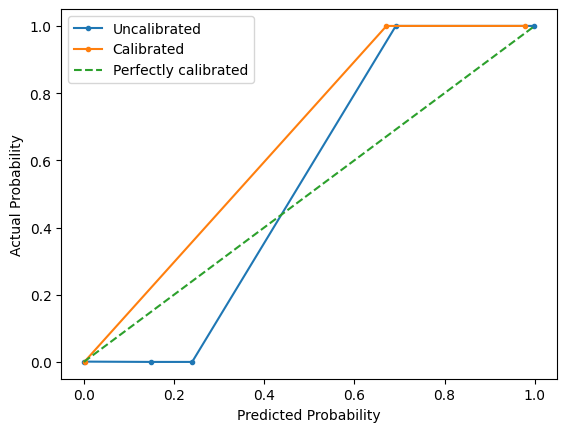

In [139]:
#4. Plot
plt.plot(predicted_uncal, actual_uncal, marker = ".", label = "Uncalibrated")
plt.plot(predicted_cal, actual_cal, marker = ".", label = "Calibrated")
plt.plot([0, 1], [0, 1], linestyle = "--", label = "Perfectly calibrated")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.legend()
plt.show()

# **Step-12: Analyzing False Positives & False Negatives**

In [165]:
# Predict probabilities
y_prob = calibrated_xgb.predict_proba(X_test)[:, 1]

# Convert probabilities to classes
y_pred = (y_prob >= 0.5).astype(int)

In [158]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred
error_analysis["Probability"] = y_prob

In [159]:
# Identify False Positive
false_positve = error_analysis[(error_analysis["Actual"] == 0) & (error_analysis["Predicted"] == 1)]
# Identify False Negative
false_negative = error_analysis[(error_analysis["Actual"] == 1) & (error_analysis["Predicted"] == 0)]

In [160]:
print("False Positive:", len(false_positve))
print("False Negative:", len(false_negative))

False Positive: 0
False Negative: 3


# **Step-13: Optimizing the Threshold**

In [161]:
from sklearn.metrics import precision_recall_curve

In [162]:
# 1. Get probabilities from the CALIBRATED model, not the old xg_model
calibrated_proba = calibrated_xgb.predict_proba(X_test)[:, 1]

In [163]:
precisions, recalls, thresholds = precision_recall_curve(y_test, calibrated_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

In [164]:
print("Best threshold:", best_threshold)

Best threshold: 0.6712224544891623


# **Step-14: Save Model**

In [154]:
import joblib

In [156]:
joblib.dump(calibrated_xgb, "Predictive Maintaince System.pkl")

['Predictive Maintaince System.pkl']

In [155]:
joblib.dump(best_threshold, "Best_Threshold.pkl")

['Best_Threshold.pkl']